# PLUMED Masterclass 21.2: Statistical errors in MD

## Aims
In this Masterclass, we will discuss how to report the results from molecular simulations. We will emphasize that any result that we get from any simulation is a random variable. To make the resut reproducible, we must characterize the distribution that has been sampled. It is not sufficient to report the averages. 

## Objective
Once you have complete this Masterclass you will be able to:
* Use PLUMED to calculate time averages and histograms from biased and unbiased simulation data. 
* Use PLUMED to perform block averaging. 
* Calculate error bars on-time averages computed from biased and unbiased simulation data using the central limit theorem and non-parameteric bootstrap. 

## Resources

The data we need is in the folder called `data`. We will find the following files in that folder:

* `uncorreleated_data:` We will analyze this data set in the first six exercises that follow
* `correleated_data:` We will analyze this data set in exercise 7
* `weighted_data:` we will analyze this data in exercise 8

In exercise 9, we will pull everything together by generating a metadynamics trajectory. This exercise draws together all the ideas from exercise 1-8 by getting you to run a metadynamics simulation and extract the free energy surface. In the `data` folder, we will thus also find the following files, which are the input for the metadynamics simulation:

* in: The input file for simplemd that contains the parameters for the MD simulaiton
* input.xyz; An initial configuration for the cluster that we are studying in this tutorial. 

## Background

In the first lesson we have see how PLUMED can be used to calculate the value of collective variables, $s(x)$, from the positions of the atoms, $x$. We also have seen that doing so allows us to describe conformational changes or chemical reactions that have occured during the molecular dynamics trajectory. We will build on this idea in this tutorial by recalling that the values for collective variable we calculate for the frame of a constant-temperature molecular dynamics trajectory are samples from the probability distribution for the canonical (NVT) ensemble:

$$P(s^{'}) = \frac{\int dx dp \delta(s(x) - s^{'}) e^{-\frac{H(x,p)}{k_{B}T}}}{\int dxdpe^{-\frac{H(x,p)}{k_BT}} } 
$$

where $k_B$ is Boltzmann's constant, T is the temperature, $H(x,p)$ is the Hamiltonian, and $\delta$ is a Dirac delta function. Notice also that the integrals in the numerator and denominator are integrals over all of phase space. If $N$ is the number of atoms in our system we must, therefore, integrate over each of the $3N$ momentum $(p)$ and $3N$ position $(x)$ coordinates when calculating these integrals.  

It is only possible to calculate the integrals in the quotient above exactly for elementary physical systems. For more complex systems we thus assume that we can extract information of $P(s^{'})$ by sampling form this distribution multiple times (using molecular dynamics or Monte Carlo) and using tools of statistics. Critically, however, any result we get from such simulations is a random variable. 

Let's first import some important packages:

In [1]:
import plumed
import matplotlib.pyplot as plt
import os
import MDAnalysis as mda
from IPython.display import Image
import numpy as np
import glob
import warnings
warnings.filterwarnings("ignore")

# set working directory for all future cells
os.chdir("/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/plumed-masterclass/masterclass-21-2/")

/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exercise 1: Calculating the average value of a CV

We will start our study of avergaging by estimating the ensemble average of the CV. The ensemble average for $s(x)$ is given by:

$$\langle S \rangle = \frac{\int dx dp s(x) e^{-\frac{H(x,p)}{k_{B}T}}}{\int dxdpe^{-\frac{H(x,p)}{k_BT}} } 
$$

In statistics, the quantity known as the ensemble average in statistical mechanics is referred to as the expectation of the random variable's distribution. The expectation of a random variable is often estimated by taking multiple identical samples from the distribution, $X_{i}$ and computing a sample mean as follows:

$$\langle X \rangle = \frac{1}{N} \sum_{i=1}^{N} X_{i} $$

We can do the same with the data from our MD trajectory. We replace the $X_i$ in the equation above with the CV values calculated for each of our trajectory frames. 

In [2]:
%%bash
# Exercise 1
# Create a directory for this exercise
mkdir Exercise-1; cd Exercise-1
# Create PLUMED input file
cat > "plumed.dat" << EOF
data: READ FILE=../data/uncorrelated_data VALUES=rand
av: AVERAGE ARG=data STRIDE=1
PRINT ARG=av FILE=COLVAR
EOF

# run the driver
plumed driver --noatoms

mkdir: Exercise-1: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from file ../data/uncorrelated_data
PLUMED:   reading value rand and storing as data
PLUMED: Action AVERAGE
PLUMED:   with label av
PLUMED:   with stride 1
PLUMED:   with arguments data
PLUMED:   doing calculation in serial
PLUMED:   

The `COLVAR` file that is output by PLUMED contains the average computed value from progressively larger and larger numbers of CV values.

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


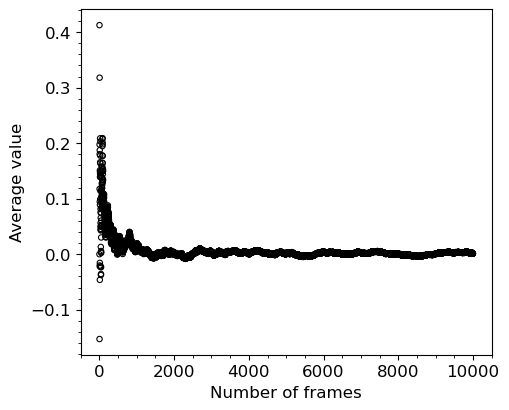

In [3]:
# import PLUMED COLVAR file into pandas dataset
plt.figure(figsize=(5, 4))
data = plumed.read_as_pandas("Exercise-1/COLVAR")
# plot progressively CV average vs number of frames
plt.scatter(data.time, 
         data.av,
         s=15,
         edgecolors="black",
         facecolor="none",
         lw=0.8)

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("Number of frames", fontsize=12)
plt.ylabel("Average value", fontsize=12)

# minor ticks
plt.minorticks_on()

plt.show()

The fluctuations in the average get smaller as this quantity is computed from larger numbers of random variables. We say that the average thus converges to the ensemble average, which is zero for the graph above. 

## Exercise 2: Calculating the free energy

We can estimate the distribution for our CV, $P(s^{'})$, by calculating a histogram. The histogram we obtain is a sample from a multimodal distribution (in the context of CV, we typically discretize its space into "bins". The multinominal distribution describes the probability of observing a specific set of counts across these bins given a total number of samples.) so can estimate parameters for the mulinomial by using likelihood maximization (is the mathematical process of finding the "true" underlying free energy values that make your observed simulaiton data most probable.). Once we have the marginal distribution, $P(s^{'})$ we can then calculate the free energy, $F(s^{'})$ as a function of $s(x)$ as $F(s^{'})$ is releated $P(s^{'})$:

$$F(s^{'}) = -k_BT\ln F(s^{'})$$

If we estimate $P(s^{'})$ using likelihood maximisation we can thus get an estimate of the free energy surface. To estimate the free energy surface for the data in `uncorrelated_data` using PLUMED in this way we can use the input file:

In [4]:
%%bash
# Exercise 2
# Create a directory for this exercise
mkdir Exercise-2; cd Exercise-2
# create PLUMED input file
cat > "plumed.dat" << EOF
# We use natural units here so that kBT is set to 1
UNITS NATURAL
data: READ FILE=../data/uncorrelated_data VALUES=rand
hhh: HISTOGRAM ARG=data STRIDE=1 GRID_MIN=-4.5 GRID_MAX=4.5 GRID_BIN=100 KERNEL=DISCRETE
fes: CONVERT_TO_FES GRID=hhh TEMP=1 # This sets k_BT=1
DUMPGRID GRID=fes FILE=fes.dat
EOF
plumed driver --noatoms

mkdir: Exercise-2: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using natural units
PLUMED:   inside PLUMED, Boltzmann constant is 1
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from 

The `--noatoms` flag here is needed since `plumed driver` is commonly used to analyze a trajectory of atomic coordinates, but here we are using it to directly analyze a collective variable. 

**N.B.-Kernel Density Estimation:** is a non-parametric statistical method used to estimate the probability density function (PDF) of a random variable from a set of data points.  In the context of CVs, it serves as a sophisticated alternative to histograms for reconstructing the free energy surface from simulation samples. 

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


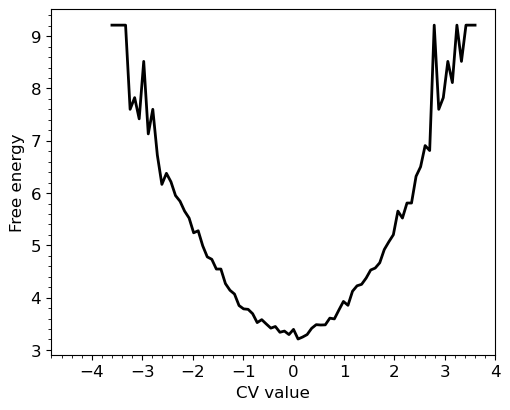

In [5]:
# import PLUMED COLVAR file into pandas dataset
plt.figure(figsize=(5, 4))
data = plumed.read_as_pandas("Exercise-2/fes.dat")
# plot progressively CV average vs number of frames
plt.plot(data.data, data.fes, color="k", lw=2)

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("CV value", fontsize=12)
plt.ylabel("Free energy", fontsize=12)

# minor ticks
plt.minorticks_on()

plt.show()

There is a single minimum in this free energy surface. 

## Exercise 3: Calculating the fluctuations for a CV

Physical systems spend the majority of their time fluctuating around minima in the free energy landscape. Let's suppose that this minima is at $\mu$ and lets use the Taylor series to write an expression for the free energy at $s^{'}$ as follows:

$$F(s) = F(\mu)+ F^{'}(\mu) (s-\mu) + \frac{F^{"}(\mu)(s-\mu)^2}{2!}+...+\frac{F^{n}(\mu)(s-\mu)^n}{n!}+..$$

In this expression $F^{'}(\mu)$, $F^{"}(\mu)$, and $F^{n}(\mu)$ are the first, second, and nth derivatives of the free energy at $\mu$. We know that there is a minimum at $\mu$ so $F^{'}(\mu)=0$. If we truncate the expansion at second order we can, therefore, write:
$$F(s) \approx F(\mu) + \frac{F^{"}(\mu)(s-\mu)^2}{2}$$

We now recall that $F(s) = -k_B T\ln P(s^{'})$ and thus write:
$$P(s) = \exp\Big(-\frac{F(s)}{k_BT}\Big) \approx \exp \Big( - \frac{F(\mu)+ \frac{F^{"}(\mu)(s-\mu)^2}{2}}{k_BT}\Big) = \exp\Big(-\frac{F(\mu)}{k_BT}\Big) \exp\Big(-\frac{F^{"}(\mu)(s-\mu)^2}{2k_BT}\Big)$$

The first term in the final product here is a constant that does not depend on $s$, while the second is a Gaussian centered on $\mu$ with $\sigma^{2} = \frac{k_BT}{F^{"}(\mu)}.$

We can assume that the constant term in the product above normalizes the distribution. The derivation above, therefore, suggests that our CV values are all samples from a normal distribution. We thus no longer need to estimate the histogram to get information on $P(s^{'})$. If $P(s^{'})$ is indeed a normal distribution, it is fully characterized if we have the two parameters: $\mu$ and $\sigma$.

Statistics tells us that if we have $N$ identical normal variables, $X_i$ we can estimate the mean $\mu$ and the standard deviation $\sigma$ using:

$$\mu = \frac{1}{N} \sum X_i$$
$$ \sigma=\sqrt{\frac{N}{N-1} \Big[ \frac{1}{N} \sum_{i}^{N} X_i^2 - \Big(\frac{1}{N} \sum_{i=1}^{N} X_i \Big)^2 \Big]} $$

We learned how to estimate $\mu$ using these expressions in exercise 1. To estimate $\sigma^2$ for the data in `uncorreleated_data` using PLUMED and the expression above we can use the following input file:

In [6]:
%%bash
# Exercise-3
mkdir Exercise-3; cd Exercise-3
# Create a PLUMED input file
cat > "plumed.dat" << EOF
UNITS NATURAL
data: READ FILE=../data/uncorrelated_data VALUES=rand
# This line should calculate the square of the quantity read in from the file above
d2: CUSTOM ARG=data FUNC=x*x PERIODIC=NO
# Calculate the average form the read-in data
av: AVERAGE ARG=data STRIDE=1
# Calculate the average of the squares of the read in data
av2: AVERAGE ARG=d2 STRIDE=1
# Evaluate the variance using the expression above
var: CUSTOM ARG=av,av2 FUNC=y-x*x PERIODIC=NO
# Print the variance
PRINT ARG=var FILE=COLVAR
EOF

# run the driver 
plumed driver --noatoms

mkdir: Exercise-3: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using natural units
PLUMED:   inside PLUMED, Boltzmann constant is 1
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from 

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


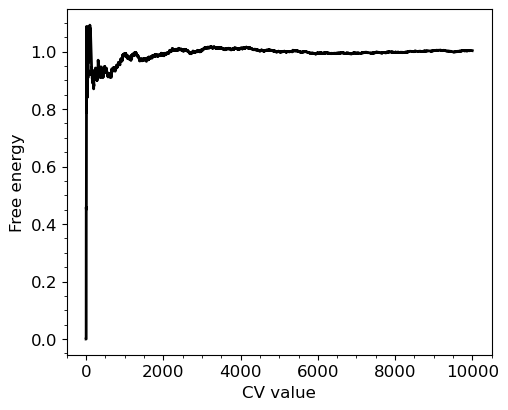

In [7]:
# import PLUMED COLVAR file into pandas dataset
plt.figure(figsize=(5, 4))
data = plumed.read_as_pandas("Exercise-3/COLVAR")
# plot progressively CV average vs number of frames
plt.plot(data["time"], data["var"], color="k", lw=2)

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("CV value", fontsize=12)
plt.ylabel("Free energy", fontsize=12)

# minor ticks
plt.minorticks_on()

plt.show()

As you can see from the graph above, $\sigma$ behaves similarily to the mean that we studied in exercise-1. 

*N.B.: Truncation the Taylor series of the free energy at second order as we have done in this section is equivalent to assuming that a Harmoninc Osciallator can be used to derive the fluctuations along our CV. The partition function, ensemble average, and distribution for such systems can be calculated exactly, and there is no need for simulaiton. Even when the system is not harmonic, calculating the quantity we have called $\sigma^2$ in this section is still useful as this quantity is an estimator for the variance of the distribution. For anharmonic systems, there is not a simple closed-form expression between the variance ($\sigma^2$ and the second derivative of the free energy at $\mu$ though.)*

## Exercise 4: Calculating block averages

The following PLUMED input splits the CV values into blocks and calculates an average from each block of data seperately. We can thus use it get information on the distribution that is being sampled when we calculate an average from sets of 500 random variables using the ideas discussed in exercise 1. 

In [8]:
%%bash
# Exercise 4
# Create directory for this exercise
mkdir Exercise-4; cd Exercise-4
# Create PLUMED input file
cat > plumed.dat << EOF
# Read the file
data: READ FILE=../data/uncorrelated_data VALUES=rand
# Clear=500 resets the accumulated average every 500 steps
av: AVERAGE ARG=data STRIDE=1 CLEAR=500
# print the current average every 500 steps
PRINT ARG=av STRIDE=500 FILE=COLVAR
EOF

plumed driver --noatoms

mkdir: Exercise-4: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from file ../data/uncorrelated_data
PLUMED:   reading value rand and storing as data
PLUMED: Action AVERAGE
PLUMED:   with label av
PLUMED:   with stride 1
PLUMED:   with arguments data
PLUMED:   doing calculation in serial
PLUMED:   

Plot a graph showing the original data from `uncorrelated_data` and the averages in the `colvar` file. You should be able to see something similar to this graph.

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


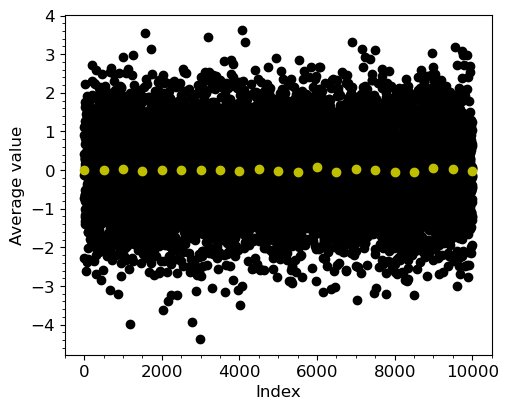

In [9]:
# import PLUMED COLVAR file into pandas dataset
plt.figure(figsize=(5, 4))
data_ex4 = plumed.read_as_pandas("Exercise-4/COLVAR")
data = plumed.read_as_pandas("data/uncorrelated_data")

# plot progressively CV average vs number of frames
plt.plot()

plt.plot(data["time"], data["rand"], "ko")
plt.plot(data_ex4["time"], data_ex4["av"], "yo", lw=2)

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("Index", fontsize=12)
plt.ylabel("Average value", fontsize=12)

# minor ticks
plt.minorticks_on()

plt.show()

Notice how the distribution for both the black (orginal data) and yellow points (averages) in this graph are centered on the same quantity. Both of these quantities are thus accurate estimators for the expectation of the distribution. However, the block average that is shown in yellow is more precise estimator for this quantity. 

The reason the block average is a more precise estimator is connected to a well known result in statistics. If we compute a mean as follows:

$$\bar{X} = \frac{1}{N} \sum_{i=1}^{N} X_{i} $$

where $X_i$ are all independent and identical random variables. It is starightforward to show that the expectation and variance of this random quantity are given by:

$$\mathbb{E}(\bar{X}) = \mathbb{E}(X)$$

and, 

$$\text{var}(\bar{X}) = \frac{\text{var}(X)}{N}$$

where $\mathbb{E}(\bar{X})$ and $\text{var}(X)$ are the expectation and variance of the random variable $X_i$ from which the mean was computed. 

In [10]:
data = plumed.read_as_pandas("data/uncorrelated_data")
data_mean = np.mean(data["rand"])
data_var = np.var(data["rand"])
print(f"Mean of the uncorrelated data: {data_mean:.5f}")
print(f"Variance of the uncorrelated data: {data_var/500:.8f}")
data_ex4 = plumed.read_as_pandas("Exercise-4/COLVAR")
data_ex4_mean = np.mean(data_ex4["av"])
data_ex4_var = np.var(data_ex4["av"])
print(f"Mean of the uncorrelated data (block average): {data_ex4_mean:.5f}")
print(f"Variance of the uncorrelated data (block average): {data_ex4_var:.8f}")

Mean of the uncorrelated data: 0.00102
Variance of the uncorrelated data: 0.00200738
Mean of the uncorrelated data (block average): 0.00119
Variance of the uncorrelated data (block average): 0.00128090


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


## Exercise 5: Free energy from block averages

**Core idea**: propage statistical uncertainty from raw data -> histogram -> free energy using block averaging. 

We can use the block averaging method introduced in exercise 4 to calculate error bars on the estimates of free energy. To generate 10 histograms from the data from the data in `uncorrelated_data` with 100 bins starting at -4 and finishing +4. 



In [11]:
%%bash
# Exercise 5
# Create
# directory for this exercise
mkdir Exercise-5; cd Exercise-5
# Create PLUMED input file
cat > "plumed.dat" << EOF
UNITS NATURAL
data: READ FILE=../data/uncorrelated_data VALUES=rand
hhh: HISTOGRAM ARG=data STRIDE=1 GRID_MIN=-4.5 GRID_MAX=4.5 GRID_BIN=100 CLEAR=1000 KERNEL=DISCRETE
DUMPGRID GRID=hhh FILE=hist.dat STRIDE=1000
EOF

plumed driver --noatoms

mkdir: Exercise-5: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using natural units
PLUMED:   inside PLUMED, Boltzmann constant is 1
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from 

Running the above command should generate 10 files containing histogram that will be called: hist.dat, analysis.0.hist.dat, ..., analysis.8.hist.dat. These files contain the histogram constructed from each blocks of data in our trajectory. We can merge them all to get the final free energy surface, which can be calculated using the well-know relation between the histogram, $P(s)$, and the free energy surface, $F(s)$. 


The value of the free energy in the $i$ th bin is calculated using:

$$F_i = -k_BT \ln(\frac{1}{N}\sum_{j=1}^{N}H_{i}^{(j)})$$

The sum here runs over the N histograms and $H_i^{j}$ is the value of the $i$ th bin in the $j$ th estimate of the histogram. 

The above equation, with considering $k_BT=1$, can be written as:
$$F_i = -\ln \langle H_{i} \rangle $$

Since $\langle H_{i} \rangle$ is estimated from finite data, it has uncertainity. The uncertainity propages into $F_i$. 

Variance of histogram across blocks is defined as,

$$s_{H_i}^2 = \frac{N}{N-1} \Big( \frac{1}{N} \sum_{j=1}^{N} (H_i^{(j)})^2 - \langle H_{i} \rangle^2 \Big)$$

This is the variance of the block histogram values. 

Standard error of the mean histogram:

$$\sigma_{H_i} = \sqrt{\frac{s_{H_i}^2}{N}}$$

Substitute the moment form:

$$\sigma_{H_i} = \sqrt{\frac{1}{N-1}\Big[\frac{1}{N} \sum_{j=1}^{N} (H_i^{(j)})^2 - \langle H_{i} \rangle^2  \Big]}$$

In order to calculate error propagation to free energy, we have to start from the free energy:

$$F_{i}(H) = -k_BT\ln H$$

Deriavative:

$$\frac{dF_i}{dH} =  - \frac{k_BT}{H}$$

Linear error propagation formulat:

$$ \sigma_{F_{i}} = \left| \frac{dF_{i}}{dH} \right|_{H=\langle H_{i} \rangle} \sigma_{H_{i}} $$

So:

$$\sigma_{F_{i}} = \frac{k_BT}{\langle H_{i} \rangle} \sigma_{H_{i}}$$

In [12]:
files = sorted(glob.glob("Exercise-5/analysis.*.hist.dat"))

hist = plumed.read_as_pandas("Exercise-5/hist.dat")
N, average, average2 = 1, hist["hhh"], hist["hhh"] * hist["hhh"]
count = 0
for f in files:
    histn = plumed.read_as_pandas(f)
    N, average, average2 = N+1, average + histn["hhh"], average2 + histn["hhh"] * histn["hhh"]
    count = count + 1

# Final averages 
average = average / N
# Final variances
var = (N/(N-1))*( average2 / N - average*average ) 
# Errors
error = np.sqrt( var / N )
# Convert to free energy 
fes = -np.log( average )
# Convert to error in fes
ferr = error / average 


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libpl

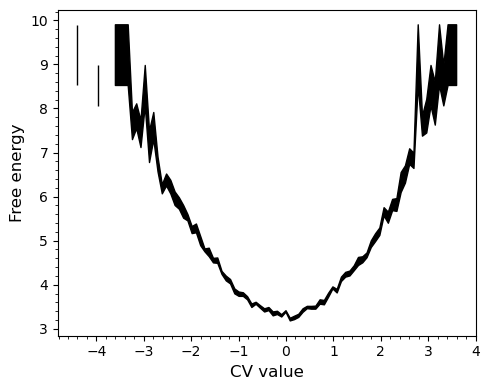

In [13]:
# And draw graph of free energy surface
plt.figure(figsize=(5,4))
plt.fill_between(hist.iloc[:,0], fes-ferr, fes+ferr, color="black")

# x-y axis labels
plt.xlabel("CV value", fontsize=12)
plt.ylabel('Free energy', fontsize=12)

# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Improve layout
plt.tight_layout()

# minor ticks
plt.minorticks_on()

plt.show()

## Exercise 6: Calculating Bootstrap Averages

In Exercise 4, we showed one way to obtain the distribution of the sample mean. There, we assumed that the M estimates of the mean were all normal random variables in the previous section but we did not need to do that. We could instead have used a non-parametric method. When using such methods we have to generate more data, which we can either do by running longer simulations, or by bootstrapping, which is cheaper. 

We can demonstrate how bootstraping works in practice by using the following script, which works with the first 500 points in `uncorrelated_data`. As you can see, we first calculate the average from all the data points. We then take new means by repeatedly sampling sets of 500 points with replacement from the data and calculating new means. 


In [14]:
ddd = np.loadtxt("data/uncorrelated_data")
data = ddd[0:1000,1]

bootstraps = np.zeros(1000)
for i in range(1000):
    av = 0
    for j in range(1000):
        av = av + data[np.random.randint(0,1000)]
    bootstraps[i] = av / 1000

f = open("bootstraps", "w")
f.write("#! FIELDS time boot \n")
for i in range(0, 1000):
    f.write(str(i) + " " + str(bootstraps[i]) + "\n")
f.close()


When we run the scripte above, it generates a file called `bootstraps` containg the averages that have been calculated by bootstrapping. If we now calculate the variance from all our bootstraped averages we should see that it close to the value we got from the expression below which was introduced in exercise 4:

$$\text{var}(\bar{x}) = \frac{\text{var}(X)}{N}$$


In [15]:
data_var = np.var(bootstraps)
# Calculate variance of bootstraps averages
nb = len(bootstraps)
mub = sum(bootstraps) / nb
varb = (nb / (nb-1)) * (sum(bootstraps * bootstraps)/nb - mub * mub)

# Calculate variance of data points
nd = len(data)
mud = sum(data) / nd
vard = (nd / (nd -1)) * (sum(data * data)/nd - mud * mud)

# var(\bar{x}) = var(x) / n
anvar = vard / nd

print(f"Bootstrap variance is: {varb:.5f}")
print(f"Analytic estimate is: {anvar:.5f}")


Bootstrap variance is: 0.00104
Analytic estimate is: 0.00099


## Exercise 7: Dealing with correlated data

In this exercise, we will review everything we have don in the previous exercises. We should: 

* Calculate block averages for the data in `correlated_data`. Calculate the error on the average of the block averages. 
* Calculate bootstrap averages for the data in `cooreleated_data`. Calculate the error from the bootstrap averages. 

In [16]:
%%bash
# Exercise 7
# Create directory for this exercise
mkdir Exercise-7; cd Exercise-7

# Create PLUMED input file
cat > plumed.dat << EOF

# Read the file
data: READ FILE=../data/correlated_data VALUES=rand

# Clear=500 resets the accumulated average every 500 steps
av: AVERAGE ARG=data STRIDE=1 CLEAR=500

# Print the current average every 500 steps
PRINT ARG=av STRIDE=500 FILE=COLVAR
EOF

plumed driver --noatoms


mkdir: Exercise-7: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from file ../data/correlated_data
PLUMED:   reading value rand and storing as data
PLUMED: Action AVERAGE
PLUMED:   with label av
PLUMED:   with stride 1
PLUMED:   with arguments data
PLUMED:   doing calculation in serial
PLUMED:   cl

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


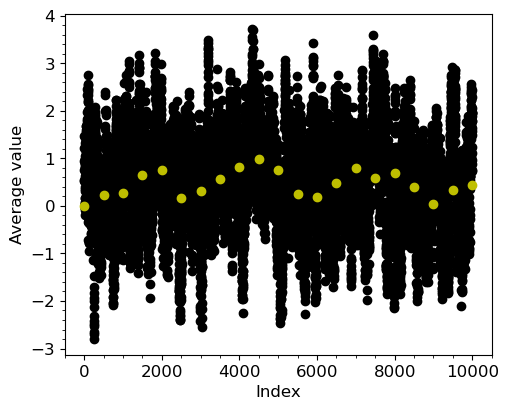

In [17]:
# import PLUMED COLVAR file into pandas dataset
plt.figure(figsize=(5, 4))
data_ex7 = plumed.read_as_pandas("Exercise-7/COLVAR")
data = plumed.read_as_pandas("data/correlated_data")

# plot progressively CV average vs number of frames
plt.plot()

plt.plot(data["time"], data["rand"], "ko")
plt.plot(data_ex7["time"], data_ex7["av"], "yo", lw=2)

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("Index", fontsize=12)
plt.ylabel("Average value", fontsize=12)

# minor ticks
plt.minorticks_on()

plt.show()

We want to calculate and compare the variance of the real data and the variance of the block-averaged data calculated from the real data. Here is the formulat to calculate the variance of the data $x$,

$$\sigma^2 = \frac{N}{N-1} \Big( \frac{1}{N} \sum_{i}^{N} x_{i}^2 - \langle x_{i} \rangle^2 \Big)$$

In [18]:
nd = len(data)
nb = len(data_ex7)

mud = sum(data["rand"]) / nd
mub = sum(data_ex7["av"]) / nb

vard = (nd/ (nd-1)) * (1/nd * sum(data["rand"] * data["rand"]) - mud*mud)
varb = (nb/ (nb-1)) * (1/nb * sum(data_ex7["av"] * data_ex7["av"]) - mub*mub)

print(f"Variance of correlated data: {vard/nb}")
print(f"Variance of the block-averaged correlated data: {varb}")

Variance of correlated data: 0.0471747978587572
Variance of the block-averaged correlated data: 0.0773984472668619


Now, we will calculate the bootstrap averages of the correlated data. 

In [19]:
ddd = np.loadtxt("data/correlated_data")
data = ddd[0:1000,1]

bootstraps = np.zeros(1000)
for i in range(1000):
    av = 0
    for j in range(1000):
        av = av + data[np.random.randint(0,1000)]
    bootstraps[i] = av / 1000

f = open("Exercise-7/bootstraps", "w")
f.write("#! FIELDS time boot \n")
for i in range(0, 1000):
    f.write(str(i) + " " + str(bootstraps[i]) + "\n")
f.close()


In [20]:
data_var = np.var(bootstraps)
# Calculate variance of bootstraps averages
nb = len(bootstraps)
mub = sum(bootstraps) / nb
varb = (nb / (nb-1)) * (sum(bootstraps * bootstraps)/nb - mub * mub)

# Calculate variance of data points
nd = len(data)
mud = sum(data) / nd
vard = (nd / (nd -1)) * (sum(data * data)/nd - mud * mud)

# var(\bar{x}) = var(x) / n
anvar = vard / nd

print(f"Bootstrap variance is: {varb:.5f}")
print(f"Analytic estimate is: {anvar:.5f}")


Bootstrap variance is: 0.00079
Analytic estimate is: 0.00082


We can see that the variance obtained from the bootstrap averages (0.0008) is less than the variance we get by block average (0.07) -> two order of magnitude higher than the bootstrap-averaged value.

These variances are different because there are correlations between the data points in `correlated_data`. Such correlations were not present in the data set we have examined in all the exercises that appeared previously to this one. The reason this matter is that this expression:

$$\text{var}(\bar{X}) = \frac{\text{var}(X)}{N}$$

is only valid if the random variables that $\bar{X}$ is computed from are both *identical* and *independent*. This expression is thus not valid for correlated data. To be clear, however, we can still write:

$$\mathbb{E}(\bar{X}) = \mathbb{E}(X)$$

as this expression holds as long as the random variable from which $\bar{X}$ are identical. When we use this expression, the random variables only need to *independent* and *can be correlated*. 

**Any data we get by computing CVs from a molecular dynamics trajectory is almost cetrain to contain correlations.** It is thus essential to know how to handle correlated data. The block averaging technique that was introduced in exercise 4 resolves this problem. We show that if the blocks are long enough, the averages we obtain are uncorrelated. 

For the remainder exercise, we should use the data in `correlated_data` and what we have learned in the previous exercise to calculate block averages for different block sizes. 

* Estimate the mean and variance for the block of length N using $\mu = \frac{1}{N} \sum_{i}^{N} X_{i}$ and $\sigma^2 = \frac{N}{N-1} \Big[ \frac{1}{N} \sum_{i}^{N} X_{i}^2 - (\frac{1}{N} \sum_{i}^{N} X_{i})^2 \Big]$
* Insert your estimate of the variance into the following expression for the error bar on your estimate for $\sigma$: $\epsilon = \sqrt{\frac{\sigma^2}{N}}$

In [21]:
%%bash
# Exercise 7a
# Create directory for this exercise
mkdir Exercise-7a; cd Exercise-7a || exit 1


for block in $(seq 5 5 70); do  
    cat > plumed.dat << EOF
data: READ FILE=../data/correlated_data VALUES=rand
av: AVERAGE ARG=data STRIDE=1 CLEAR=${block}
PRINT ARG=av STRIDE=${block} FILE=COLVAR-${block}
EOF
    echo "#############################"
    echo "Running block size = ${block}"
    echo "#############################"
    plumed driver --noatoms
done

mkdir: Exercise-7a: File exists


#############################
Running block size = 5
#############################
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from file ../data/correlated_data
PLUMED:   reading value rand and storing as data
PLUMED: Action AVERAGE
PLUMED:   with label av
PLUMED:   with stride

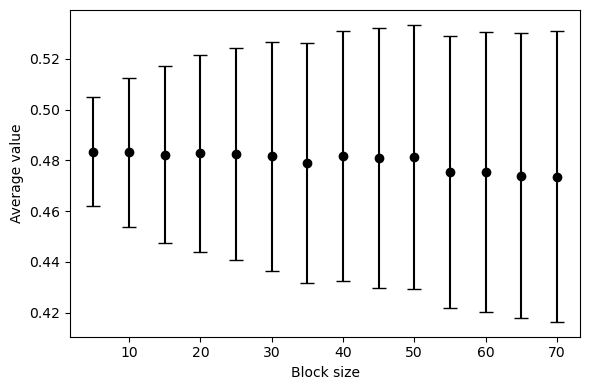

In [22]:
block_sizes = list(range(5, 71, 5))
means = []
stds = []

for block in block_sizes:
    fname = f"Exercise-7a/COLVAR-{block}"
    
    if not os.path.exists(fname):
        print(f"Warning: {fname} not found, skipping")
        means.append(np.nan)
        stds.append(np.nan)
        continue

    data = []

    with open(fname, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            # Usually the last column is the averaged value
            data.append(float(parts[-1]))

    data = np.array(data)

    means.append(np.mean(data))
    lb = len(data)
    mub = sum(data) / lb

    std = np.sqrt(1/(lb-1) * (sum(data * data)/lb - (mub * mub)))
    stds.append(std)   # sample standard deviation

means = np.array(means)
stds = np.array(stds)

# Save results
out = np.column_stack([block_sizes, means, stds])
np.savetxt(
    "block_average_stats.dat",
    out,
    header="block_size mean std",
    fmt=["%d", "%.8f", "%.8f"]
)

# Plot
plt.figure(figsize=(6,4))
plt.errorbar(block_sizes, means, yerr=stds, color="black", fmt='o', capsize=5)
plt.xlabel("Block size")
plt.ylabel("Average value")
plt.tight_layout()
#plt.savefig("block_average_plot.png", dpi=300)
plt.show()

When the underlying data are correlated, block averages constructed from too few data points remain statistically dependent. In this regime, the estimated error bars are systematically underestimated because the assumption of independent samples is violated. As the block size increases, each block average incorporated more data and the correlation between successive blocks diminshes. Once the block size exceeds the correlation time of the system, the block averages become effectively independent, and the estimated error converges to stable, block-size-independent value. At this point, the relation $\text{var}(\bar{X}) = \frac{\text{var}(X)}{N}$ becomes valid, where $N$ is the size of the block. 

## Exercise 8: Weighted averages

PLUMED is routinely used to run simulations using methods such as umbrella sampling and metadynmics. In these methods, a bias potential, $V(x)$, is added to the Hamiltonian to enhance the sampling of phase space. CVs calculated from the frames of such biased MD simulations thus samples from the following distribution:

$$P(s^{'}) = \frac{\int dx dp \delta(s(x) - s^{'}) e^{-\frac{H(x,p)}{k_BT}} e^{-\frac{V(x)}{k_BT}}}{\int dx dp e^{-\frac{H(x,p)}{k_BT}} e^{-\frac{V(x)}{k_BT}}},$$

However, in most cases the quantity of interest is the unbiased distribution, which is given by:

$$P(s^{'}) = \frac{\int dx dp \delta(s(x) - s^{'}) e^{-\frac{H(x,p)}{k_BT}}}{\int dx dp e^{-\frac{H(x,p)}{k_BT}}},$$

To recover this unbiased information from biased simulations, one must correct for the effect of the bias. This is acheived by computing weighted averages of observables:

$$\bar{X}_{\omega} = \frac{\sum_{i}^{N} \omega_i X_i}{\sum_{i}^{N}\omega_i}$$

where the weights $\omega_i$ are the chosen to compensate for the bias (their explicit form depends on the simulation method). 

In this exercise, we reweight the data contained in `weighted_data`, which consists of samples drawn from the distribution:

$$P(x) = \frac{1}{\sqrt{2\pi\sigma}} \exp\Big( - \frac{(x-\mu)^2}{2\sigma^2}\Big),$$

with $\mu=0.6$ and $\sigma=0.5$, and with the additional constraint that $x \in [0, 1]$. Using the information, the weighted average

$$\bar{X}_{\omega} = \frac{\sum_{i}^{N} \omega_i X_i}{\sum_{i}^{N} \omega_i}, \text{ where } \omega_i = \frac{1}{P(X_i)},$$

provdes an estimator for the expectation value of a uniform random variable in the interval $[0, 1]$. 

The variance of the reweighted distribution can be estimates as:

$$\sigma_x^2 = \frac{V_1}{V_1 - 1} \sum_{i=1}^{N} \frac{\omega_i}{V_1} (X_i - \bar{X}_{\omega}), \text{ with } V_1 = \sum_{i}^{N} \omega_i $$

which corresponds to the varinace of the target (uniform) distribution after reweighting. 

Finally, statistical theory provides expression for the expectation value and variance of the weighted average itself: 

$$\mathbb{E}(\bar{X}_{\omega}) = \bar{X}, \text{       } \text{var}(\bar{X}_{\omega}) = \frac{\sum_{i=1}^{N} \omega_i^2 (X_i - \bar{X}_{\omega})^2}{(\sum_{i=1}^{N} \omega_i)^2}$$

where $X$ is the underlying random variable (true distribution).

These expression are valid provided that the $X_i$ are independent and identically distributed. Notably, unlike the case of unweighted averages, $\text{var}(\bar{X}) = \text{var}(X)/N$, the variance of the weighted average $(\text{var}(\bar{X}_{\omega}))$ is not simply proportional to the variance of the underlying variable ($\text{var}(X)$).

In what follows, the goal is to compute averages, fluctuations, and free energies for the unbiased (uniform) distribution by applying these reweighting procedures. In addition, weighted histograms will be constructed, and uncertainties will be estimate directely from the reweighted data. 


In [23]:
%%bash
# Exercise 8
# Create directory for this exercise
mkdir Exercise-8; cd Exercise-8

# Create PLUMED input file
cat > plumed.dat << EOF
UNITS NATURAL # This ensure that Boltzmann's constant is one
data: READ FILE=../data/weighted_data VALUES=rand IGNORE_FORCES
# This restraint and the REWEIGT_BIAS command after computes the weights in the formulas above. 
mm: RESTRAINT ARG=data AT=0.6 KAPPA=4
# This command computes the log-weights needed to remove the effect of the bias (TEMP=1 means temperature T=1)
rw: REWEIGHT_BIAS TEMP=1
# Compute weighted average
wav: AVERAGE ARG=data STRIDE=1 LOGWEIGHTS=rw
# Compute squared deviations from the weighted mean
dd: CUSTOM ARG=data,wav FUNC=(x-y)*(x-y) PERIODIC=NO
# Compute weighted sum of squared devations
uvar: AVERAGE ARG=dd STRIDE=1 LOGWEIGHTS=rw NORMALIZATION=false
# Define a constant equal to 1
one: CONSTANT VALUE=1
# Compute the sum of weights
wsum: AVERAGE ARG=one STRIDE=1 LOGWEIGHTS=rw NORMALIZATION=false
# Compute the weighted variance
var: CUSTOM ARG=uvar,wsum FUNC=x/(y-1) PERIODIC=NO
# Print out the averages and variance of the uniform random variable
PRINT ARG=wav,var STRIDE=1 FILE=COLVAR
# Construct the histogram
hhh: HISTOGRAM ARG=data LOGWEIGHTS=rw GRID_MIN=0 GRID_MAX=1 GRID_BIN=20 CLEAR=1000 NORMALIZATION=true KERNEL=DISCRETE
# Dump the histogram to file
DUMPGRID GRID=hhh FILE=hist.dat STRIDE=1000
EOF

plumed driver --noatoms

mkdir: Exercise-8: File exists


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 0
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using natural units
PLUMED:   inside PLUMED, Boltzmann constant is 1
PLUMED: Action READ
PLUMED:   with label data
PLUMED:   with stride 1
PLUMED:   reading data from 

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


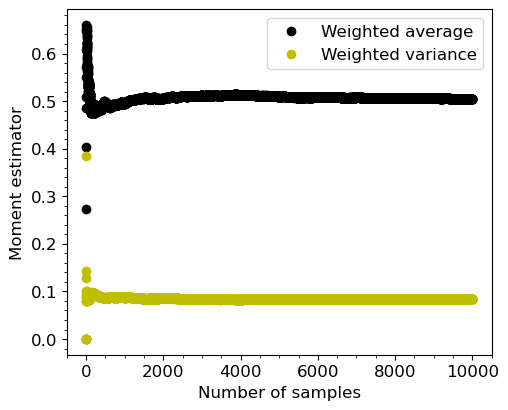

In [24]:
# import PLUMED COLVAR file into pandas dataset
plt.figure(figsize=(5, 4))
data = plumed.read_as_pandas("Exercise-8/COLVAR")

# plot progressively time vs mean and time vs variance
plt.plot(data["time"], data["wav"], "ko", label="Weighted average")
plt.plot(data["time"], data["var"], "yo", label="Weighted variance")

# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("Number of samples", fontsize=12)
plt.ylabel("Moment estimator", fontsize=12)

# minor ticks
plt.minorticks_on()

# Legend
plt.legend(prop={'size': 12})

plt.show()

In [25]:
# Function to read in histogram data and normalization
def readhistogram(file):
    # Read in the histogram data
    data = np.loadtxt(file)
    with open(file, "r") as f:
        for l in f:
            if l.startswith("#! SET normalisation"):
                norm = l.split()[3]
    return float(norm), data

# Calculate weighted average
norm1, hist1 = readhistogram("Exercise-8/hist.dat")
N, average = norm1, norm1 * hist1[:, 1]


for filen in glob.glob("Exercise-8/analysis.*.hist.dat"):
    norm, histn = readhistogram(filen)
    N, average = N + norm, average + norm * histn[:, 1]

average = average / N

# Calculate errors
norm1, hist1 = readhistogram("Exercise-8/hist.dat")
error = norm1 * norm1 * (hist1[:,1] - average)**2

for filen in glob.glob("Exercise-8/analysis.*.hist.dat"):
    norm, histn = readhistogram(filen)
    error = error + norm * norm * (histn[:, 1] - average)**2

error = np.sqrt((error / (N*N)))

# Convert to free energy
fes = -np.log(average)

# Convert to error in fes
ferr = error / average

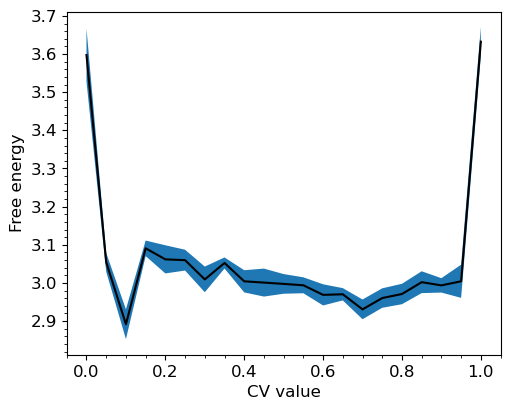

In [26]:
# And draw graph of free energy surface
plt.figure(figsize=(5, 4))

plt.fill_between( hist1[:,0], fes-ferr, fes+ferr )
plt.plot( hist1[:,0], fes, 'k-' )


# Ticks formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Improve layout
plt.tight_layout()

# labels
plt.xlabel("CV value", fontsize=12)
plt.ylabel("Free energy", fontsize=12)

# minor ticks
plt.minorticks_on()


plt.show()



## Exercise 9: The free energy from a biased simulation

We now combine the previous ideas to extract a free energy surface from a metadynamics simulation using reweighting. The earlier exercises established three essential points:

(i) The quantities obtained from simulations are statistical estimates, so error bars must always be reported to assess reliability and reproducibility.  
(ii) When a bias is present, observables must be computed using weighted averages to recover unbiased properties.  
(iii) Because consecutive frames are correlated, block averaging must be to obtain multiple independent estimates and reliable error bars.  

With these prinicples in place, we now apply them in a practical example. The theoretical background of metadynanics is discussed in Masterclass-21.4. 

We consider a system of seven Lennard-Jones atoms in two dimensions, simulated using the MD code `simplemd` provided with PLUMED. The simulation can be run with:

```console
plumed simplemd < in
```

The input file `in` (from the tutorial repository) runs 200000 MD steps at temperature $k_BT = 0.1 \epsilon$, starting from the configuration in `input.xyz`. 

The timestep is $0.005\sqrt{\epsilon m \sigma^2}$, and temperature is controlled using a Langevin thermostat with relaxation time $0.1 \sqrt{\epsilon m \sigma^2}$. Configurations are written every 1000 steps to `trajectory.xyz`. A PLUMED input file (`plumed.dat`) must be provided. 

The goal is to study transitions between four stable configurations of the 7-atom cluster. During metadynamics, however, the cluster may dissociate (atoms drift apart). To prevent this, we introduce a restraint that keeps all atoms within a fixed distance from the centre of mass. 

The centre of mass is defined as:

$$x_{\text{com}} = \frac{1}{N} \sum_{i}^{N} x_i$$

For each atom $i$, we compute its distance from the centre of mass, $d_i$. A restrained is then applied:


$$
V(d_i) = \begin{cases} 100\,(d_i - 2.0)^2 & \text{if } d_i < 2 \\ 0 & \text{otherwise} \end{cases}
$$

This potential does nothing when atoms are within distance 2 of the centre of mass, but if an atom moves further away, it is pushed back. In this way, the cluster remains intact. 


To drive transitions between different structures, we apply a metadynamics bias. This bias is constructed using collective variables (CVs) that describe the structure of the system. 

First, we define the coordination number for each atom:


$$ c_i = \sum_{j \neq i} \frac{1 - (r_{ij}/1.5)^8}{1 - (r_{ij}/1.5)^{16}} $$

From these coordination numbers, we construct statistical moments of their distribution. The $n$-th central moment is:

$$\mu^n = \frac{1}{N} \sum_{i=1}^{N} (c_i - \langle c \rangle)^n  \text{  with  } \langle c \rangle = \frac{1}{N} \sum_{i=1}^{N} c_{i} $$

In this exercise, the second and third moments are used as collective variables (CVs). These quantities capture the shape of the coordination-number distribution and distinguish different structural configurations. 

In [52]:
%%bash
# Exercise 9
# Create directory for this exercise
mkdir Exercise-9; cd Exercise-9

# Create PLUMED input file
cat > plumed.dat << EOF
# This tells PLUMED we are using Lennared Jones units
UNITS NATURAL
# Calculate the position of the centre of mass. We can then refere to this position later in the input using
# label com. 
COM ATOMS=1-7 LABEL=com
# Add the restraint on the distance between com and the first atom
DISTANCE ATOMS=1,com LABEL=d1
UPPER_WALLS ARG=d1 AT=2.0 KAPPA=100.0
# Add the restraint on the distance between com and the second atom
DISTANCE ATOMS=2,com LABEL=d2
UPPER_WALLS ARG=d2 AT=2.0 KAPPA=100.0
# Add the restraint on the distance between com and the third atom
DISTANCE ATOMS=3,com LABEL=d3
UPPER_WALLS ARG=d3 AT=2.0 KAPPA=100.0
# Add the restraint on the distance between com and the fourth atom
DISTANCE ATOMS=4,com LABEL=d4
UPPER_WALLS ARG=d4 AT=2.0 KAPPA=100.0
# Add the restraint on the distance between com and the five atom
DISTANCE ATOMS=5,com LABEL=d5
UPPER_WALLS ARG=d5 AT=2.0 KAPPA=100.0
# Add the restraint on the distance between com and the six atom
DISTANCE ATOMS=6,com LABEL=d6
UPPER_WALLS ARG=d6 AT=2.0 KAPPA=100.0
# Add the restraint on the distance between com and the seven atom
DISTANCE ATOMS=7,com LABEL=d7
UPPER_WALLS ARG=d7 AT=2.0 KAPPA=100.0
c1: COORDINATIONNUMBER SPECIES=1-7 MOMENTS=2-3 SWITCH={RATIONAL R_0=1.5 NN=8 MM=16}
METAD ...
ARG=c1.* HEIGHT=0.05 PACE=500 SIGMA=0.1,0.1 
GRID_MIN=-1.5,-1.5 GRID_MAX=2.5,2.5 GRID_BIN=500,500 
BIASFACTOR=5
...
EOF



mkdir: Exercise-9: File exists


In [54]:
!cp data/in Exercise-9/
!cp data/input.xyz Exercise-9/
!cd Exercise-9/ && plumed simplemd < in

Starting configuration           : input.xyz
Final configuration              : output.xyz
Number of atoms                  : 7
Temperature                      : 0.100000
Time step                        : 0.005000
Friction                         : 1.000000
Cutoff for forces                : 2.500000
Cutoff for neighbour list        : 3.000000
Number of steps                  : 1000000
Stride for trajectory            : 100
Trajectory file                  : trajectory.xyz
Stride for statistics            : 1000
Statistics file                  : energies.dat
Dimensionality                   : 2
Seed                             : 0
Are atoms wrapped on output?     : F
Epsilon                          : 1.000000
Sigma                            : 1.000000
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plum

Once we have run the metadynamics calculations, we can post-process the output trajectory using **driver** to extract the free energy by reweighting. Notice that to do block averaging, we will need to extract multiple estimates for the (weighted) histogram. We should thus use the following input file to extract estimates of the histogram. 

In [ ]:
# Create PLUMED input file
cat > plumed_reweight.dat << EOF
UNITS NATURAL
